In [1]:
# Se importan las herramientas para representar intereses y construir segmentos reproducibles.

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfTransformer

In [2]:
# Se cargan perfiles de estudiantes y sus menciones de intereses.

data = pd.read_csv("../data/snsdata.csv")
data.head()

,gradyear,gender,age,friends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2006,M,18.982,7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2006,F,18.801,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,2006,M,18.335,69,0,1,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,2006,F,18.875,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2006,NaN,18.995,10,0,0,0,0,0,0,...,0,0,2,0,0,0,0,0,1,1


In [3]:
# ¿Qué edades requieren corrección antes de caracterizar los grupos?

data["age_clean"] = data["age"].where(data["age"].between(13, 20, inclusive="left"))
age_medians = data.groupby("gradyear")["age_clean"].median()
data["age_imputed"] = data["age_clean"].fillna(data["gradyear"].map(age_medians))
data[["gradyear", "age", "age_imputed", "friends"]].describe()

,gradyear,age,age_imputed,friends
count,30000.000000,24914.000000,30000.000000,30000.000000
mean,2007.500000,17.993950,17.234014,30.179467
std,1.118053,7.858054,1.145224,36.530877
min,2006.000000,3.086000,13.027000,0.000000
25%,2006.750000,16.312000,16.282000,3.000000
50%,2007.500000,17.287000,17.238000,20.000000
75%,2008.250000,18.259000,18.212000,44.000000
max,2009.000000,106.927000,19.995000,830.000000


In [4]:
# Se separan intereses usados para agrupar de atributos usados solo para caracterizar.

interest_columns = data.columns[4:40].tolist()
profile_columns = ["gradyear", "gender", "age_imputed", "friends"]
len(interest_columns), profile_columns

(36, ['gradyear', 'gender', 'age_imputed', 'friends'])

In [5]:
# La silueta permite justificar cuántos segmentos conservan separación suficiente antes de interpretarlos.

from sklearn.metrics import silhouette_score

tfidf = TfidfTransformer()
interest_matrix = tfidf.fit_transform(data[interest_columns])

cluster_selection = []
for n_clusters in range(2, 9):
    candidate = KMeans(n_clusters=n_clusters, n_init=10, random_state=42).fit(interest_matrix)
    cluster_selection.append({"n_clusters": n_clusters, "silhouette_score": silhouette_score(interest_matrix, candidate.labels_, sample_size=3000, random_state=42)})
cluster_selection = pd.DataFrame(cluster_selection)
cluster_selection

,n_clusters,silhouette_score
0,2,0.055084
1,3,0.066805
2,4,0.078749
3,5,0.090541
4,6,0.105816
5,7,0.106620
6,8,0.119878


In [6]:
# Se ponderan intereses y se asignan cinco grupos con una semilla reproducible.

tfidf = TfidfTransformer()
interest_matrix = tfidf.fit_transform(data[interest_columns])
kmeans = KMeans(n_clusters=5, n_init=30, random_state=42)
data["cluster"] = kmeans.fit_predict(interest_matrix)
cluster_sizes = data["cluster"].value_counts().sort_index().rename("n").to_frame()
cluster_sizes["percentage"] = (100 * cluster_sizes["n"] / len(data)).round(2)
cluster_sizes

,n,percentage
cluster,,
0,3251,10.84
1,2230,7.43
2,17448,58.16
3,3870,12.90
4,3201,10.67


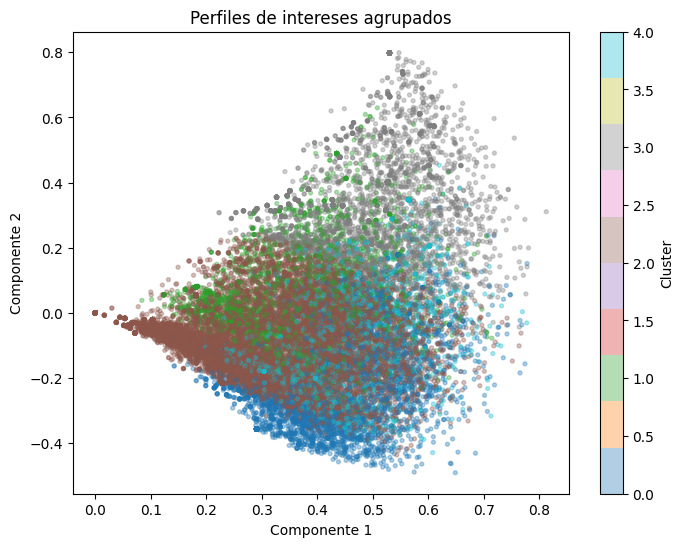

In [7]:
# La proyección bidimensional no crea los clusters: solo permite inspeccionar visualmente su separación en el espacio de intereses.

import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

projection = TruncatedSVD(n_components=2, random_state=42).fit_transform(interest_matrix)
plt.figure(figsize=(8, 6))
plt.scatter(projection[:, 0], projection[:, 1], c=data["cluster"], cmap="tab10", alpha=0.35, s=8)
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.title("Perfiles de intereses agrupados")
plt.colorbar(label="Cluster")
plt.savefig("../submission/cluster-scatter.png", bbox_inches="tight")
plt.show()

In [8]:
# ¿Qué ocho intereses distinguen a cada grupo respecto de los demás?

centers = pd.DataFrame(kmeans.cluster_centers_, columns=interest_columns)
top_interests = []
for cluster_id in centers.index:
    for interest, score in centers.loc[cluster_id].nlargest(8).items():
        top_interests.append({"cluster": cluster_id, "interest": interest, "score": score})
top_interests = pd.DataFrame(top_interests).sort_values(
    ["cluster", "score"], ascending=[True, False]
).reset_index(drop=True)

In [9]:
# La comparación por columnas hace visibles los intereses que caracterizan cada cluster y su importancia relativa.

cluster_interest_table = pd.DataFrame(
    {
        f"Cluster {cluster}": group.apply(
            lambda row: f"{row['interest']} ({row['score']:.3f})",
            axis=1,
        ).to_list()
        for cluster, group in top_interests.groupby("cluster", sort=True)
    },
    index=range(1, 9),
)
cluster_interest_table.index.name = "Importancia"
cluster_interest_table

,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4
Importancia,,,,,
1,dance (0.613),band (0.653),hair (0.092),music (0.617),god (0.587)
2,music (0.118),music (0.138),shopping (0.086),rock (0.100),music (0.118)
3,shopping (0.095),marching (0.137),cute (0.085),shopping (0.097),church (0.116)
4,hair (0.090),rock (0.066),basketball (0.081),hair (0.063),jesus (0.082)
5,cute (0.085),god (0.065),mall (0.075),cute (0.058),shopping (0.072)
6,god (0.068),hair (0.058),football (0.073),mall (0.051),cute (0.065)
7,mall (0.062),shopping (0.053),soccer (0.072),die (0.048),hair (0.064)
8,rock (0.054),cute (0.053),music (0.057),sports (0.044),die (0.060)


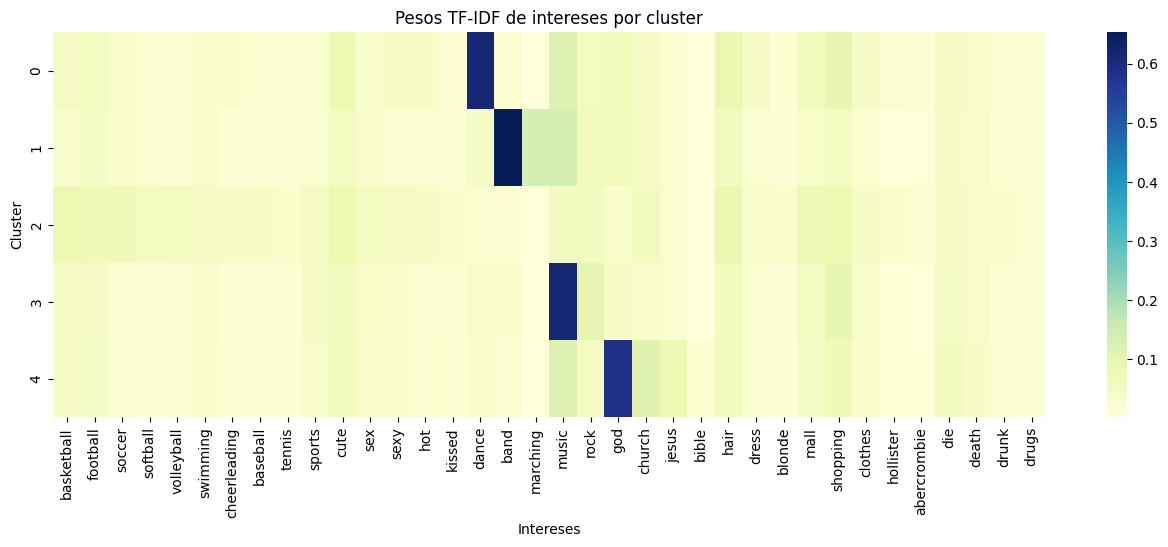

In [10]:
# El heatmap permite comparar todos los intereses entre clusters antes de reducir la interpretación a unos pocos términos principales.

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 5))
sns.heatmap(centers, cmap="YlGnBu", xticklabels=interest_columns, yticklabels=centers.index)
plt.xlabel("Intereses")
plt.ylabel("Cluster")
plt.title("Pesos TF-IDF de intereses por cluster")
plt.xticks(rotation=90)
plt.savefig("../submission/interests-heatmap.png", bbox_inches="tight")
plt.show()

In [11]:
# Los nombres son etiquetas interpretativas basadas en los intereses dominantes; no son categorías observadas en los datos.

cluster_names = {0: "Danza", 1: "Banda y marcha", 2: "Intereses mixtos", 3: "Música y rock", 4: "Religión"}
data["cluster_name"] = data["cluster"].map(cluster_names)
pd.DataFrame(cluster_names.items(), columns=["cluster", "nombre interpretativo"])

,cluster,nombre interpretativo
0,0,Danza
1,1,Banda y marcha
2,2,Intereses mixtos
3,3,Música y rock
4,4,Religión


In [12]:
# Se calculan perfiles complementarios sin usar edad ni género para construir los segmentos.

data["gender_profile"] = data["gender"].fillna("Unknown")
cluster_profiles = data.groupby("cluster").agg(n=("cluster", "size"), age_mean=("age_imputed", "mean"), friends_mean=("friends", "mean")).round(2)
gender_profiles = pd.crosstab(data["cluster"], data["gender_profile"], normalize="index").mul(100).round(1)
gradyear_profiles = pd.crosstab(data["cluster"], data["gradyear"], normalize="index").mul(100).round(1)
cluster_profiles.join(cluster_sizes[["percentage"]])

,n,age_mean,friends_mean,percentage
cluster,,,,
0,3251,17.08,32.64,10.84
1,2230,17.29,31.43,7.43
2,17448,17.21,29.96,58.16
3,3870,17.33,26.61,12.90
4,3201,17.37,32.32,10.67


In [13]:
# Se conservan las evidencias para que la interpretación de los grupos ocurra durante la clase.

from pathlib import Path

submission_dir = Path("../submission")
data.to_csv(submission_dir / "segmented.csv", index=False)
cluster_sizes.reset_index().to_csv(submission_dir / "cluster_sizes.csv", index=False)
top_interests.to_csv(submission_dir / "top_interests.csv", index=False)
cluster_profiles.reset_index().to_csv(submission_dir / "cluster_profiles.csv", index=False)
gender_profiles.reset_index().to_csv(submission_dir / "gender_profiles.csv", index=False)
gradyear_profiles.reset_index().to_csv(submission_dir / "gradyear_profiles.csv", index=False)